# DREF Map Visualizations
This notebook builds the map products from the wrangled outputs created in Notebook 05.

The visual direction should follow humanitarian cartography norms similar to organizations such as UNHCR: restrained basemaps, editorial labeling, soft contrast, and institutional clarity over decorative effects.

In [23]:

from functools import lru_cache
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from matplotlib.lines import Line2D
from xyzservices import TileProvider


In [24]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
MAP_OUTPUT_DIR = DATA_DIR / 'outputs' / 'map_figures'
MAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

country_quarter = pd.read_csv(PROCESSED_DIR / 'dref_map_country_quarter.csv')
region_quarter = pd.read_csv(PROCESSED_DIR / 'dref_map_region_quarter.csv')
top10_countries = pd.read_csv(PROCESSED_DIR / 'dref_map_top10_countries.csv')
top5_disasters = pd.read_csv(PROCESSED_DIR / 'dref_map_top5_disasters.csv')

country_quarter.head()

,year_quarter,quarter_index,country_clean,Region,modality_family,pillar_group,disaster_top5_group,total_approved_chf,api_country_name,iso3,longitude,latitude
0,2022 Q1,1,Afghanistan,Asia-Pacific,DREF,Response,Other,260046,Afghanistan,AFG,67.709953,33.939110
1,2022 Q1,1,Ethiopia,Africa,Loans,Response,Other,507108,Ethiopia,ETH,39.655151,8.559294
2,2022 Q1,1,Ethiopia,Africa,Loans,Response,Population Movement,400000,Ethiopia,ETH,39.655151,8.559294
3,2022 Q1,1,"Iran, Islamic Republic of",MENA,DREF,Response,Flood,499506,"Iran, Islamic Republic of",IRN,53.688046,32.427908
4,2022 Q1,1,"Iran, Islamic Republic of",MENA,Loans,Response,Other,438000,"Iran, Islamic Republic of",IRN,53.688046,32.427908


In [25]:
CONFIG_DIR = DATA_DIR / 'config'
MAPBOX_CONFIG_PATH = CONFIG_DIR / 'mapbox.local.json'

if MAPBOX_CONFIG_PATH.exists():
    import json
    mapbox_config = json.loads(MAPBOX_CONFIG_PATH.read_text(encoding='utf-8'))
else:
    mapbox_config = {
        'mapbox_token': '',
        'style_url': 'mapbox://styles/go-ifrc/clvvgugzh00x501pc1n00b8cz',
        'country_tileset_url': 'mapbox://go-ifrc.go-countries',
        'country_source_layer': 'go-countries',
        'country_join_key': 'iso3'
    }

mapbox_config

{'mapbox_token': 'MAPBOX_TOKEN_REDACTED',
 'style_url': 'mapbox://styles/go-ifrc/ckrfe16ru4c8718phmckdfjh0',
 'country_tileset_url': 'mapbox://go-ifrc.go-countries',
 'country_source_layer': 'go-countries',
 'country_join_key': 'iso3'}

In [26]:
HUMANITARIAN_MODES = {
    'background': '#F7F5F0',
    'land': '#ECE7DD',
    'water': '#DCE8EC',
    'outline': '#B8B1A3',
    'text': '#24313A'
}

MODALITY_COLORS = {
    'DREF': '#B4612D',
    'i-DREF': '#2C7178',
    'EAP / EA grants': '#AD914C',
    's-EAP': '#627A54',
    'Loans': '#345C8C',
    'a-DREF': '#848484'
}

plt.rcParams.update({
    'figure.facecolor': HUMANITARIAN_MODES['background'],
    'axes.facecolor': HUMANITARIAN_MODES['background'],
    'font.size': 11,
    'font.family': 'DejaVu Sans',
})

HUMANITARIAN_MODES


{'background': '#F7F5F0',
 'land': '#ECE7DD',
 'water': '#DCE8EC',
 'outline': '#B8B1A3',
 'text': '#24313A'}

In [27]:

MAPBOX_TOKEN = str(mapbox_config.get('mapbox_token', '')).strip()
HAS_MAPBOX_TOKEN = bool(MAPBOX_TOKEN)
MAPBOX_STYLE_URL = mapbox_config.get('style_url', 'mapbox://styles/go-ifrc/ckrfe16ru4c8718phmckdfjh0')
PLOTLY_MAP_STYLE = MAPBOX_STYLE_URL if HAS_MAPBOX_TOKEN else 'carto-positron'
NON_MAPBOX_TILE_PROVIDER = cx.providers.CartoDB.Positron
NATURAL_EARTH_COUNTRIES_URL = 'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'

if HAS_MAPBOX_TOKEN:
    px.set_mapbox_access_token(MAPBOX_TOKEN)


def _mapbox_style_to_provider(style_url, token):
    if not token or not style_url.startswith('mapbox://styles/'):
        return None
    owner_and_style = style_url.replace('mapbox://styles/', '', 1)
    style_owner, style_id = owner_and_style.split('/', 1)
    return TileProvider(
        name='IFRC Mapbox Style',
        url=(
            f'https://api.mapbox.com/styles/v1/{style_owner}/{style_id}/tiles/512/'
            f'{{z}}/{{x}}/{{y}}@2x?access_token={token}'
        ),
        attribution='© Mapbox © OpenStreetMap contributors',
        tileSize=512,
        max_zoom=18,
    )


MAPBOX_TILE_PROVIDER = _mapbox_style_to_provider(MAPBOX_STYLE_URL, MAPBOX_TOKEN)
MAP_STYLE_URL = PLOTLY_MAP_STYLE

_valid_coords = country_quarter[['latitude', 'longitude']].dropna()
_center_lat = float(_valid_coords['latitude'].mean())
_center_lon = float(_valid_coords['longitude'].mean())


@lru_cache(maxsize=1)
def load_world_boundaries():
    try:
        world = gpd.read_file(NATURAL_EARTH_COUNTRIES_URL)
        return world.to_crs(epsg=3857)
    except Exception as exc:
        print(f'World boundary fallback unavailable: {exc}')
        return None


def make_point_gdf(df, lon_col='longitude', lat_col='latitude'):
    plot_df = df.dropna(subset=[lon_col, lat_col]).copy()
    return gpd.GeoDataFrame(
        plot_df,
        geometry=gpd.points_from_xy(plot_df[lon_col], plot_df[lat_col]),
        crs='EPSG:4326',
    ).to_crs(epsg=3857)


def set_map_extent(ax, gdf, pad_ratio=0.16, min_pad=350000):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    xpad = max((xmax - xmin) * pad_ratio, min_pad)
    ypad = max((ymax - ymin) * pad_ratio, min_pad * 0.8)
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)



def plot_static_bubble_map(
    plot_df,
    title,
    subtitle,
    basemap='non_mapbox',
    label_col='label',
    legend_handles=None,
    extent_pad_ratio=0.16,
):
    gdf = make_point_gdf(plot_df)
    provider = MAPBOX_TILE_PROVIDER if basemap == 'mapbox' and MAPBOX_TILE_PROVIDER is not None else NON_MAPBOX_TILE_PROVIDER
    world = load_world_boundaries()

    fig, ax = plt.subplots(figsize=(13.5, 8.2), dpi=150)
    fig.patch.set_facecolor(HUMANITARIAN_MODES['background'])
    ax.set_facecolor(HUMANITARIAN_MODES['water'])

    set_map_extent(ax, gdf, pad_ratio=extent_pad_ratio)

    if world is not None:
        world.plot(
            ax=ax,
            color=HUMANITARIAN_MODES['land'],
            edgecolor=HUMANITARIAN_MODES['outline'],
            linewidth=0.45,
            alpha=0.95,
            zorder=1,
        )

    try:
        cx.add_basemap(
            ax,
            source=provider,
            crs=gdf.crs,
            attribution_size=7,
            zoom='auto',
            reset_extent=False,
            alpha=0.55,
        )
    except Exception as exc:
        print(f'Basemap tiles unavailable, using vector fallback only: {exc}')

    if world is not None:
        world.boundary.plot(
            ax=ax,
            color=HUMANITARIAN_MODES['outline'],
            linewidth=0.35,
            alpha=0.7,
            zorder=2,
        )

    ax.scatter(
        gdf.geometry.x,
        gdf.geometry.y,
        s=gdf['bubble_area'] * 1.45,
        color='#FFFFFF',
        alpha=0.40,
        linewidths=0,
        zorder=3,
    )
    ax.scatter(
        gdf.geometry.x,
        gdf.geometry.y,
        s=gdf['bubble_area'],
        color=gdf['bubble_color'],
        edgecolors='#FFFFFF',
        linewidths=1.3,
        alpha=0.92,
        zorder=4,
    )

    xmin, ymin, xmax, ymax = gdf.total_bounds
    x_span = xmax - xmin
    y_span = ymax - ymin

    for row in gdf.itertuples():
        dx = x_span * (0.018 if row.geometry.x <= (xmin + xmax) / 2 else -0.018)
        dy = y_span * (0.016 if row.geometry.y <= (ymin + ymax) / 2 else -0.016)
        ha = 'left' if dx > 0 else 'right'
        va = 'bottom' if dy > 0 else 'top'
        ax.text(
            row.geometry.x + dx,
            row.geometry.y + dy,
            getattr(row, label_col),
            fontsize=9.5,
            fontweight='bold',
            color=HUMANITARIAN_MODES['text'],
            ha=ha,
            va=va,
            zorder=5,
            path_effects=[pe.withStroke(linewidth=3, foreground='white')],
        )

    ax.text(
        0.0,
        1.045,
        title,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        color=HUMANITARIAN_MODES['text'],
    )
    ax.text(
        0.0,
        1.005,
        subtitle,
        transform=ax.transAxes,
        fontsize=10.5,
        color='#5C6870',
    )

    if legend_handles:
        ax.legend(
            handles=legend_handles,
            loc='lower left',
            frameon=True,
            facecolor='#FFFFFF',
            edgecolor='none',
            fontsize=9,
        )

    ax.set_axis_off()
    plt.tight_layout()
    return fig, ax


print(f'Mapbox token available: {HAS_MAPBOX_TOKEN}')
print(f"Non-Mapbox static basemap: {NON_MAPBOX_TILE_PROVIDER['name']}")
print(f'Mapbox static basemap active: {MAPBOX_TILE_PROVIDER is not None}')
print(f'Plotly style: {MAP_STYLE_URL}')
print(f'Map center: lat={_center_lat:.1f}, lon={_center_lon:.1f}')


Mapbox token available: True
Non-Mapbox static basemap: CartoDB.Positron
Mapbox static basemap active: True
Plotly style: mapbox://styles/go-ifrc/ckrfe16ru4c8718phmckdfjh0
Map center: lat=15.4, lon=52.8


In [28]:
region_summary = (
    region_quarter.groupby('Region', as_index=False)['total_approved_chf']
                 .sum()
                 .sort_values('total_approved_chf', ascending=False)
)

fig_region = px.bar(
    region_summary,
    x='total_approved_chf',
    y='Region',
    orientation='h',
    title='Regional Allocations, 2022 Q1 to 2026 Q1',
    labels={'total_approved_chf': 'Approved CHF'}
)
fig_region.update_layout(
    template='plotly_white',
    paper_bgcolor=HUMANITARIAN_MODES['background'],
    plot_bgcolor=HUMANITARIAN_MODES['background'],
    font={'color': HUMANITARIAN_MODES['text']},
    yaxis={'categoryorder': 'total ascending'}
)

fig_region

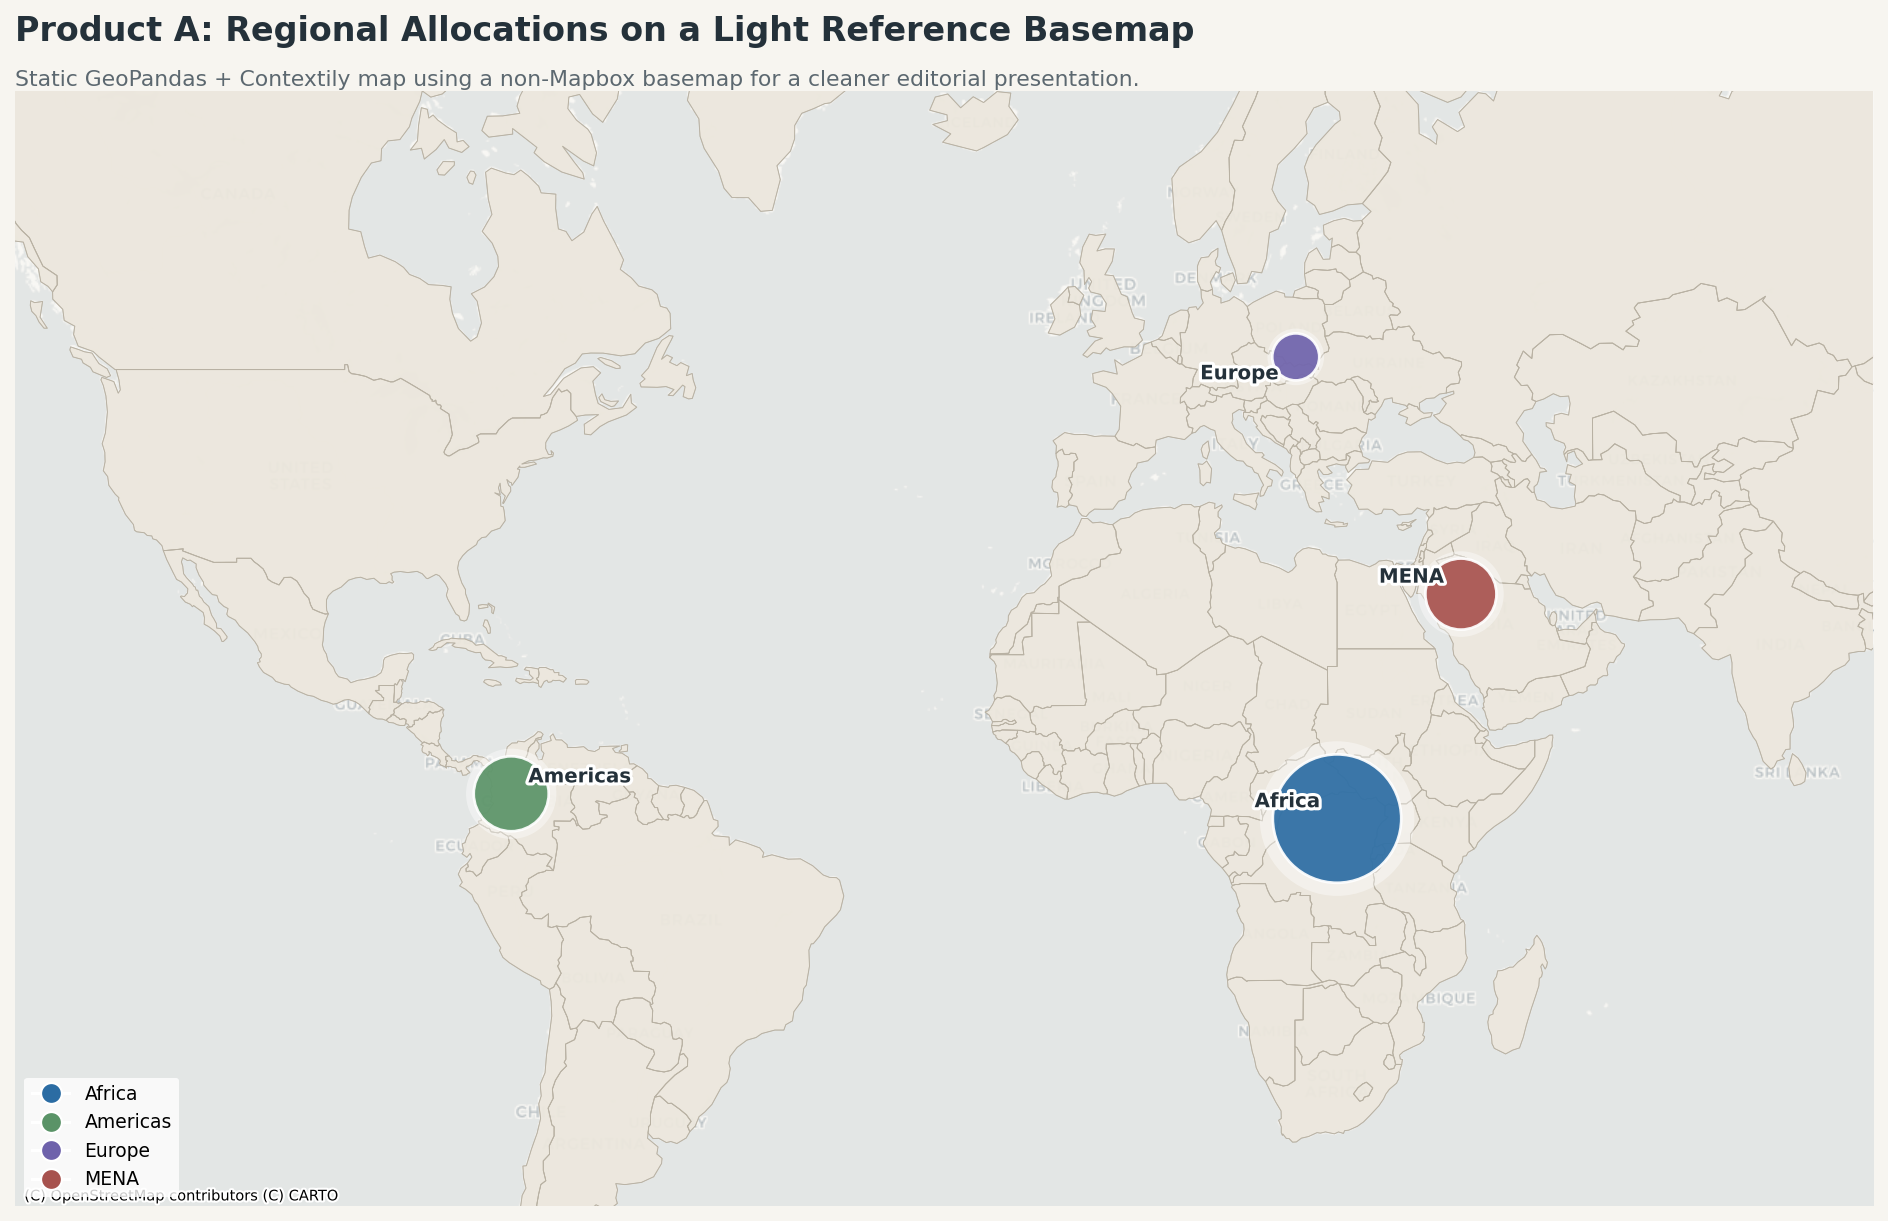

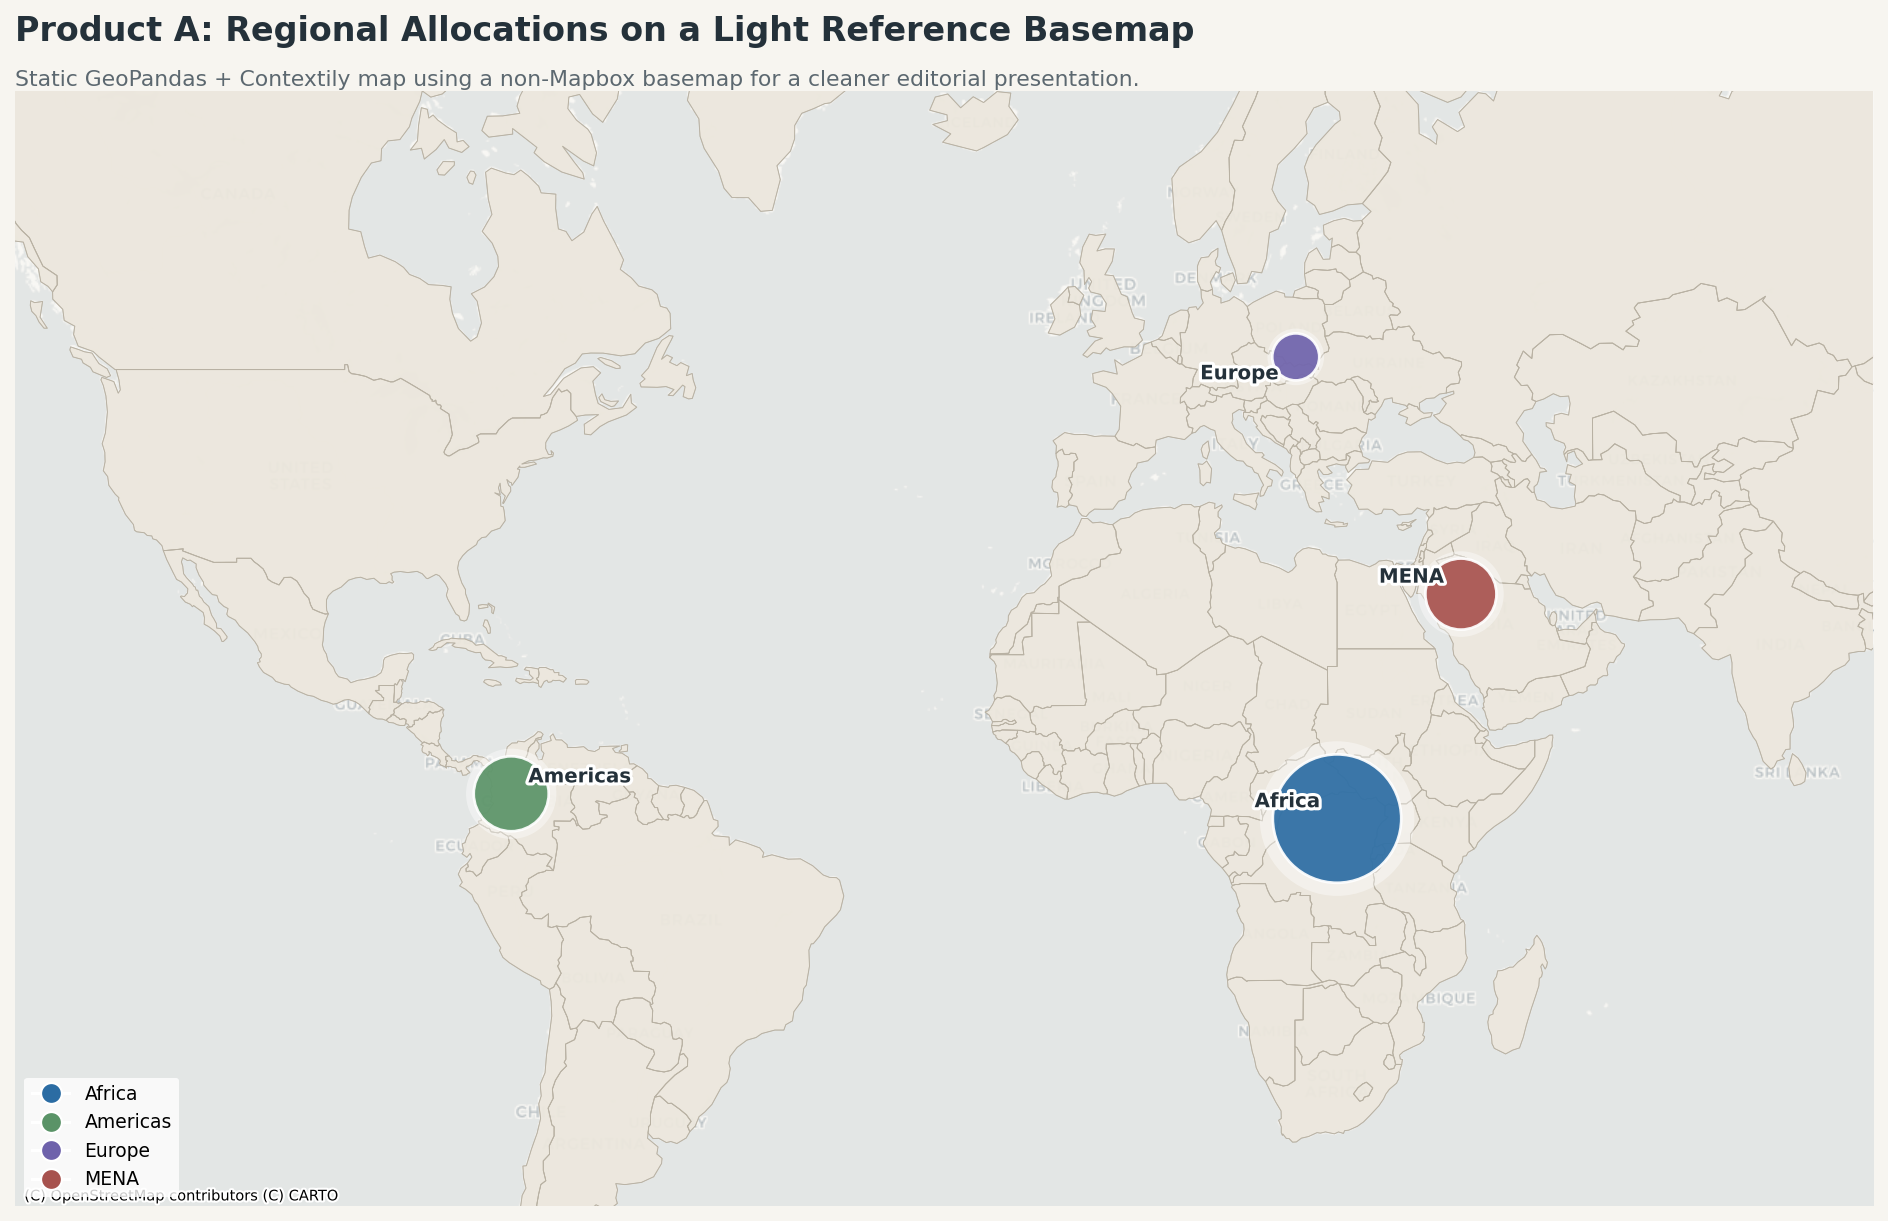

In [29]:

# Product A: Regional static bubble map on a refined non-Mapbox basemap
REGION_CENTROIDS_LOOKUP = {
    'Africa': {'longitude': 25.0, 'latitude': 2.0},
    'Americas': {'longitude': -75.0, 'latitude': 5.0},
    'Asia Pacific': {'longitude': 118.0, 'latitude': 15.0},
    'Europe': {'longitude': 20.0, 'latitude': 50.0},
    'Middle East and North Africa': {'longitude': 40.0, 'latitude': 28.0},
    'MENA': {'longitude': 40.0, 'latitude': 28.0},
}

REGION_COLOR_LOOKUP = {
    'Africa': '#2B6CA3',
    'Americas': '#5A9367',
    'Asia Pacific': '#BE7839',
    'Europe': '#6E62AB',
    'Middle East and North Africa': '#A7524E',
    'MENA': '#A7524E',
}

region_map_data = region_summary.copy()
region_map_data['longitude'] = region_map_data['Region'].map(
    lambda region: REGION_CENTROIDS_LOOKUP.get(region, {}).get('longitude')
)
region_map_data['latitude'] = region_map_data['Region'].map(
    lambda region: REGION_CENTROIDS_LOOKUP.get(region, {}).get('latitude')
)
region_map_data = region_map_data.dropna(subset=['longitude', 'latitude']).copy()

max_region_chf = region_map_data['total_approved_chf'].max()
region_map_data['bubble_area'] = (
    (region_map_data['total_approved_chf'] / max_region_chf) * 3800
).clip(lower=500)
region_map_data['bubble_color'] = region_map_data['Region'].map(
    lambda region: REGION_COLOR_LOOKUP.get(region, '#2B6CA3')
)
region_map_data['label'] = region_map_data['Region']

region_legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=region, markerfacecolor=color, markersize=10)
    for region, color in REGION_COLOR_LOOKUP.items()
    if region in region_map_data['Region'].unique()
]

fig_region_static, ax_region_static = plot_static_bubble_map(
    region_map_data,
    title='Product A: Regional Allocations on a Light Reference Basemap',
    subtitle='Static GeoPandas + Contextily map using a non-Mapbox basemap for a cleaner editorial presentation.',
    basemap='non_mapbox',
    legend_handles=region_legend_handles,
    extent_pad_ratio=0.22,
)

fig_region_static


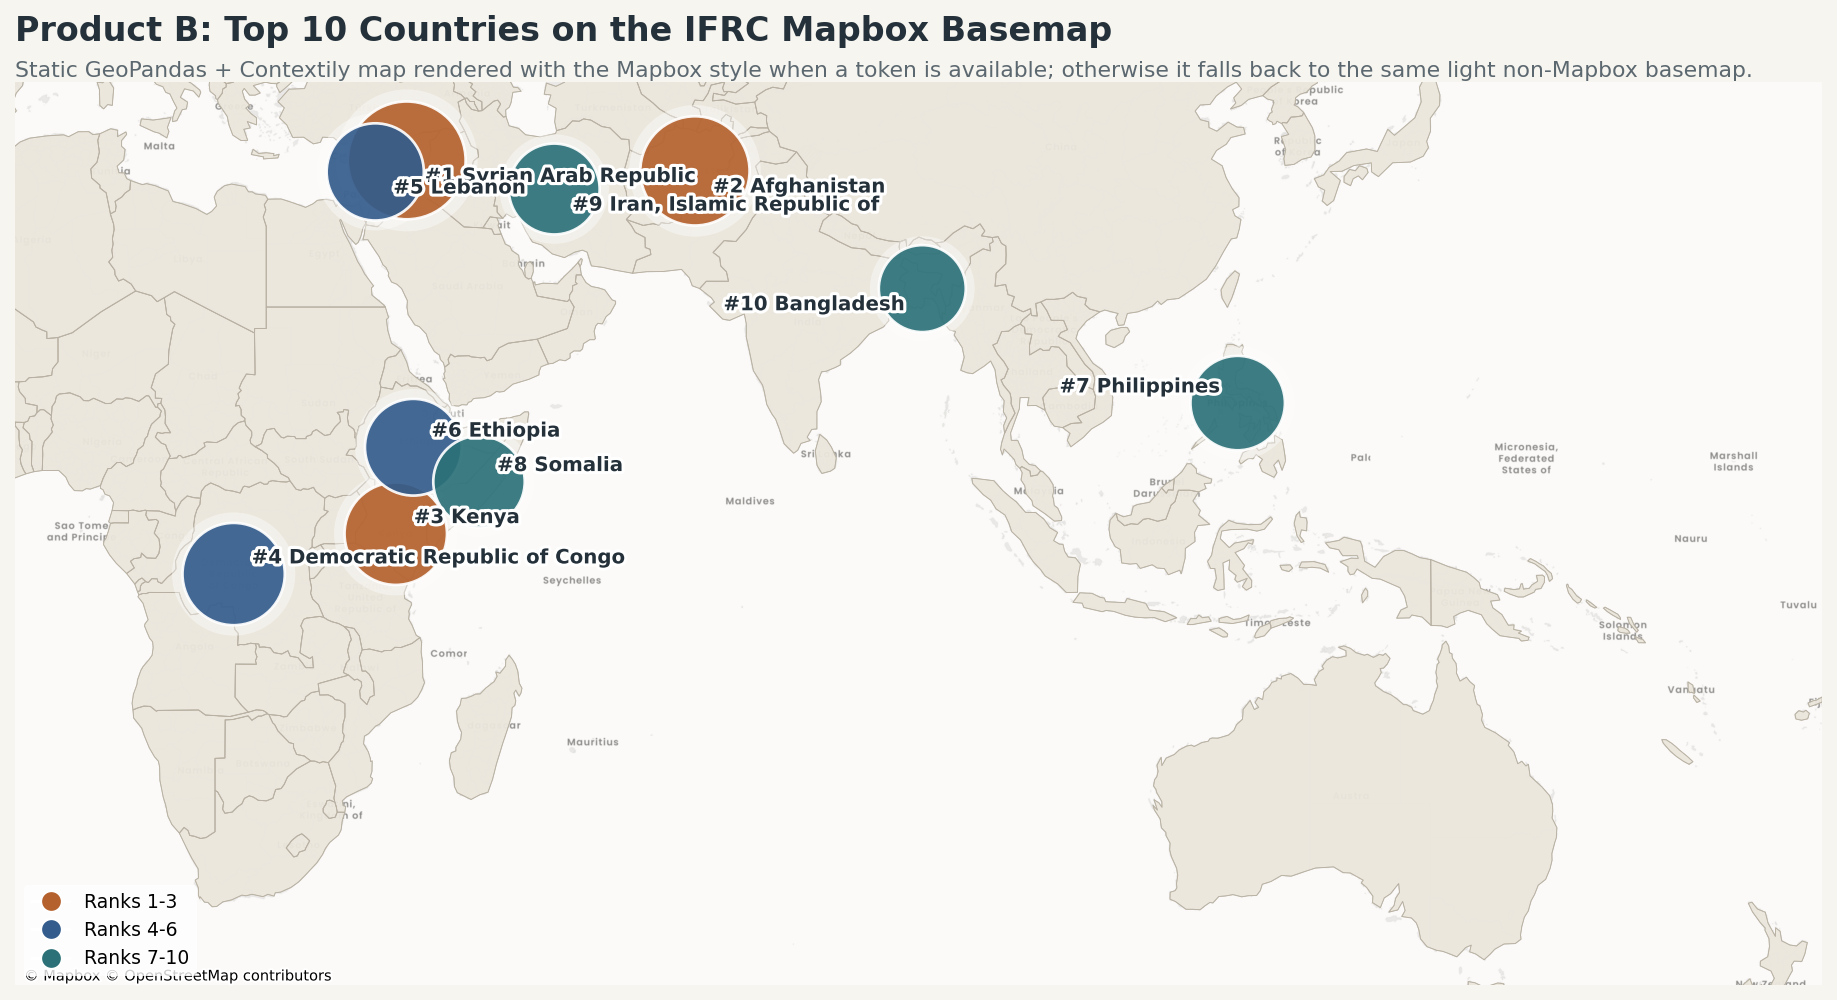

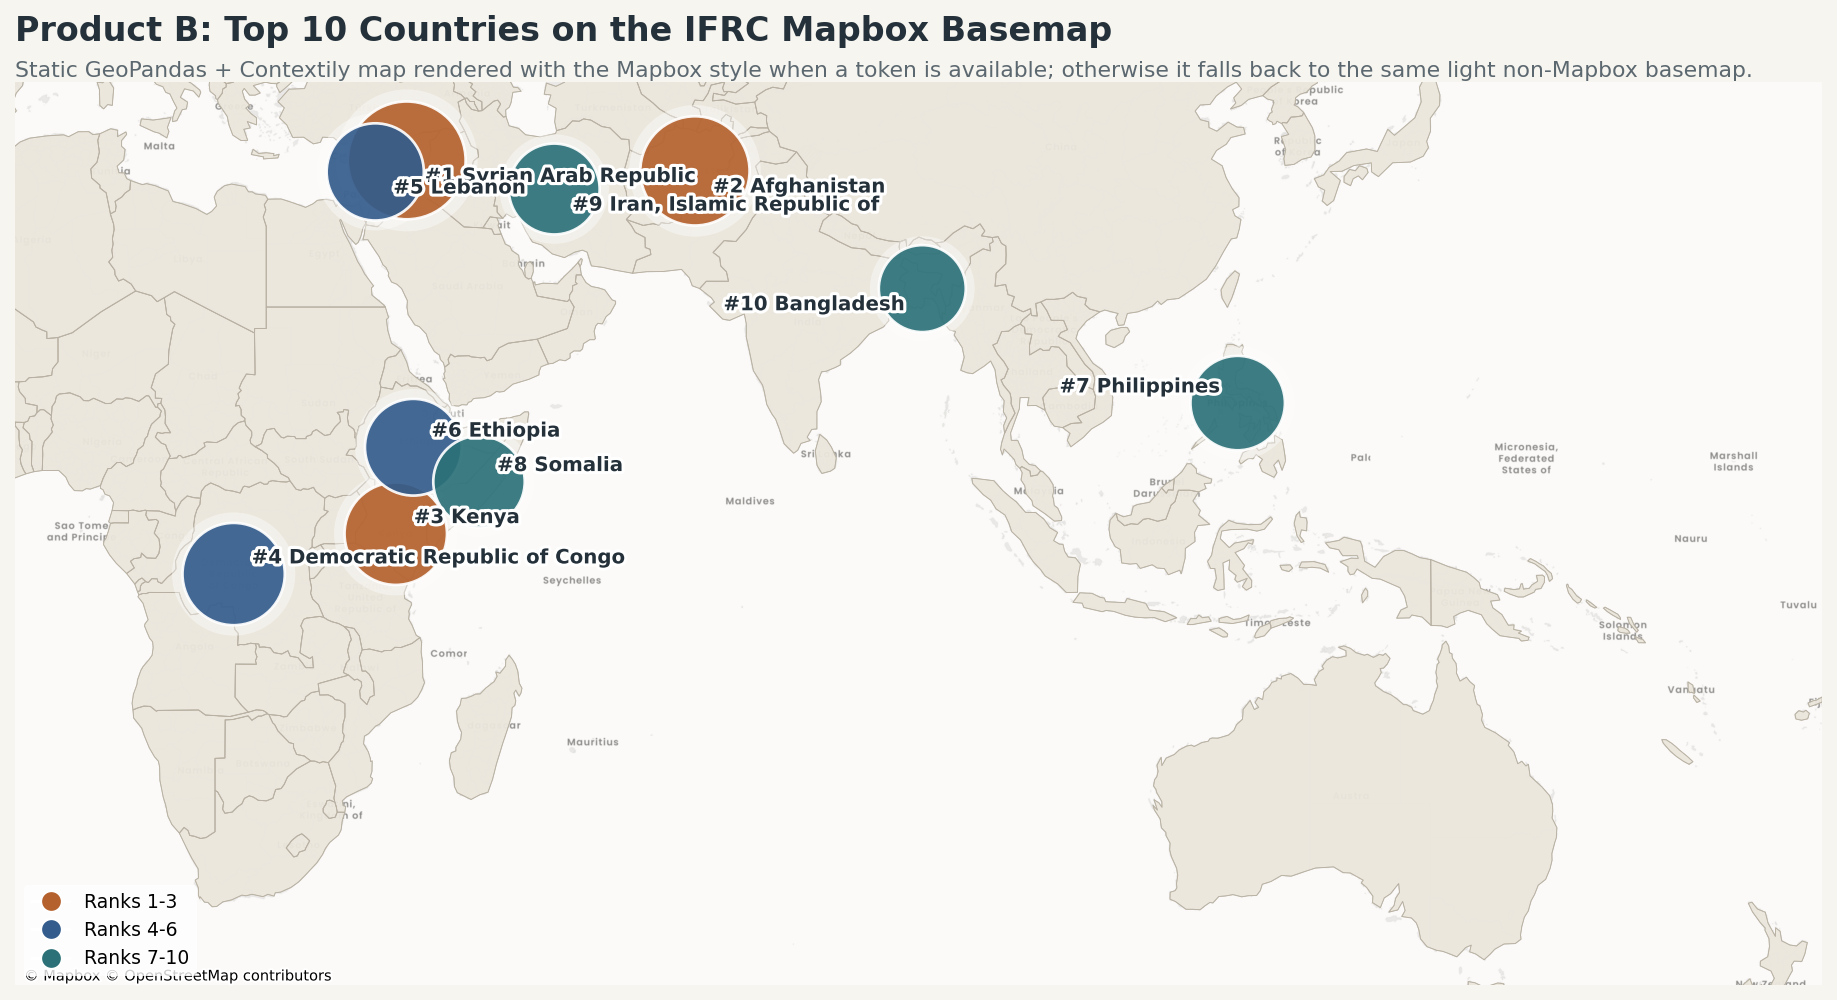

In [30]:

# Product B: Top 10 country static bubble map using the Mapbox style as raster tiles
_coord_ref = country_quarter[['country_clean', 'iso3', 'longitude', 'latitude']].drop_duplicates('country_clean')

top10_latest = (
    country_quarter.groupby('country_clean', as_index=False)['total_approved_chf']
    .sum()
    .merge(_coord_ref, on='country_clean', how='left')
    .dropna(subset=['longitude', 'latitude'])
    .sort_values('total_approved_chf', ascending=False)
    .head(10)
    .copy()
)

top10_latest['rank'] = np.arange(1, len(top10_latest) + 1)
max_chf = top10_latest['total_approved_chf'].max()
top10_latest['bubble_area'] = (
    (top10_latest['total_approved_chf'] / max_chf) * 3200
).clip(lower=220)

def rank_color(rank):
    if rank <= 3:
        return '#B4612D'
    if rank <= 6:
        return '#345C8C'
    return '#2C7178'

top10_latest['bubble_color'] = top10_latest['rank'].apply(rank_color)
top10_latest['chf_display'] = top10_latest['total_approved_chf'].apply(lambda value: f"{value:,.0f}")
top10_latest['share_pct'] = (
    top10_latest['total_approved_chf'] / top10_latest['total_approved_chf'].sum() * 100
).round(1)
top10_latest['label'] = top10_latest.apply(
    lambda row: f"#{int(row['rank'])} {row['country_clean']}", axis=1
)

top10_legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Ranks 1-3', markerfacecolor='#B4612D', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Ranks 4-6', markerfacecolor='#345C8C', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Ranks 7-10', markerfacecolor='#2C7178', markersize=10),
]

fig_top10_static, ax_top10_static = plot_static_bubble_map(
    top10_latest,
    title='Product B: Top 10 Countries on the IFRC Mapbox Basemap',
    subtitle=(
        'Static GeoPandas + Contextily map rendered with the Mapbox style when a token is available; '
        'otherwise it falls back to the same light non-Mapbox basemap.'
    ),
    basemap='mapbox',
    legend_handles=top10_legend_handles,
    extent_pad_ratio=0.18,
)

fig_top10_static


In [31]:

# Build cumulative animation frames with Grants vs Loans breakdown for Product C.
# "Loans" stays as-is; everything else (DREF, i-DREF, EAP/EA grants, s-EAP, a-DREF) → "Grants"
country_quarter['funding_category'] = np.where(
    country_quarter['modality_family'] == 'Loans', 'Loans', 'Grants'
)

quarter_order = sorted(country_quarter['quarter_index'].dropna().unique())

qi_to_label = (
    country_quarter[['quarter_index', 'year_quarter']]
    .drop_duplicates()
    .set_index('quarter_index')['year_quarter']
    .to_dict()
)

_coord_ref_anim = country_quarter[['country_clean', 'iso3', 'longitude', 'latitude']].drop_duplicates('country_clean')

frames = []
for quarter in quarter_order:
    frame = (
        country_quarter[country_quarter['quarter_index'] <= quarter]
            .groupby(['country_clean', 'funding_category'], as_index=False)['total_approved_chf']
            .sum()
            .assign(
                frame_quarter=quarter,
                year_quarter_label=qi_to_label.get(quarter, str(int(quarter)))
            )
    )
    frame = frame.merge(_coord_ref_anim, on='country_clean', how='left')
    frames.append(frame)

cumulative_frames = pd.concat(frames, ignore_index=True)
cumulative_frames.to_csv(PROCESSED_DIR / 'dref_map_animation_frames.csv', index=False)

print(f"Animation frames: {len(cumulative_frames)} rows across {len(quarter_order)} quarters")
print(f"Funding categories: {cumulative_frames['funding_category'].value_counts().to_dict()}")
cumulative_frames.head()


Animation frames: 298 rows across 18 quarters
Funding categories: {'Grants': 169, 'Loans': 129}


,country_clean,funding_category,total_approved_chf,frame_quarter,year_quarter_label,iso3,longitude,latitude
0,Afghanistan,Grants,260046,1,2022 Q1,AFG,67.709953,33.939110
1,Ethiopia,Loans,907108,1,2022 Q1,ETH,39.655151,8.559294
2,"Iran, Islamic Republic of",Grants,499506,1,2022 Q1,IRN,53.688046,32.427908
3,"Iran, Islamic Republic of",Loans,438000,1,2022 Q1,IRN,53.688046,32.427908
4,Kenya,Grants,212853,1,2022 Q1,KEN,37.906193,-0.023559


In [32]:

# Product C: Quarter-by-quarter cumulative animation on IFRC Mapbox basemap
# Bubbles are colored by funding category (Grants vs Loans) so the composition
# of each country's allocation is visible as it grows quarter by quarter.

quarter_labels_sorted = sorted(cumulative_frames['year_quarter_label'].unique())

max_chf_anim = cumulative_frames['total_approved_chf'].max()
anim_plot = cumulative_frames.copy()
anim_plot['bubble_size'] = (
    np.sqrt(anim_plot['total_approved_chf'] / max_chf_anim) * 40
).clip(lower=3)

fig_anim = px.scatter_mapbox(
    anim_plot,
    lat='latitude',
    lon='longitude',
    size='bubble_size',
    color='funding_category',
    color_discrete_map={
        'Grants': '#345C8C',   # humanitarian deep blue
        'Loans':  '#B4612D',   # warm ochre
    },
    hover_name='country_clean',
    hover_data={
        'year_quarter_label': True,
        'total_approved_chf': ':,.0f',
        'funding_category': True,
        'bubble_size': False,
        'latitude': False,
        'longitude': False,
    },
    animation_frame='year_quarter_label',
    category_orders={'year_quarter_label': quarter_labels_sorted},
    size_max=40,
    zoom=2.0,
    center={'lat': _center_lat, 'lon': _center_lon},
    opacity=0.8,
)
fig_anim.update_layout(
    mapbox_style=MAP_STYLE_URL,
    mapbox_accesstoken=MAPBOX_TOKEN,
    paper_bgcolor=HUMANITARIAN_MODES['background'],
    font={'color': HUMANITARIAN_MODES['text']},
    title='Product C: Cumulative DREF Allocations — Grants vs Loans, 2022 Q1 to 2026 Q1',
    legend_title_text='Funding Category',
    margin=dict(l=0, r=0, t=40, b=0),
    height=650,
)

fig_anim


C:\Users\arun.gandhi\AppData\Local\Temp\ipykernel_8132\541747138.py:13: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_anim = px.scatter_mapbox(


In [33]:

# Product D: Top 10 countries segmented by disaster definition (scatter_mapbox + IFRC basemap)
_coord_ref_d = country_quarter[['country_clean', 'iso3', 'longitude', 'latitude']].drop_duplicates('country_clean')

disaster_agg = (
    country_quarter
    .groupby(['country_clean', 'disaster_top5_group'], as_index=False)['total_approved_chf']
    .sum()
    .merge(_coord_ref_d, on='country_clean', how='left')
)

max_dis_chf = disaster_agg['total_approved_chf'].max()
disaster_agg['bubble_size'] = (
    np.sqrt(disaster_agg['total_approved_chf'] / max_dis_chf) * 35
).clip(lower=3)

fig_disaster = px.scatter_mapbox(
    disaster_agg,
    lat='latitude',
    lon='longitude',
    size='bubble_size',
    color='disaster_top5_group',
    hover_name='country_clean',
    hover_data={
        'total_approved_chf': ':,.0f',
        'disaster_top5_group': True,
        'bubble_size': False,
        'latitude': False,
        'longitude': False,
    },
    size_max=35,
    zoom=2.0,
    center={'lat': _center_lat, 'lon': _center_lon},
    opacity=0.8,
)
fig_disaster.update_layout(
    mapbox_style=MAP_STYLE_URL,
    mapbox_accesstoken=MAPBOX_TOKEN,
    paper_bgcolor=HUMANITARIAN_MODES['background'],
    font={'color': HUMANITARIAN_MODES['text']},
    title='Product D: Top 10 Countries by Disaster Definition',
    legend_title_text='Disaster Group',
    margin=dict(l=0, r=0, t=40, b=0),
    height=650,
)

fig_disaster


C:\Users\arun.gandhi\AppData\Local\Temp\ipykernel_8132\4023233557.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_disaster = px.scatter_mapbox(


In [34]:

# Pillar segmentation: Anticipatory vs Response (scatter_mapbox + IFRC basemap)
pillar_agg = (
    country_quarter
    .groupby(['country_clean', 'pillar_group'], as_index=False)['total_approved_chf']
    .sum()
    .merge(_coord_ref_d, on='country_clean', how='left')
)

max_pillar_chf = pillar_agg['total_approved_chf'].max()
pillar_agg['bubble_size'] = (
    np.sqrt(pillar_agg['total_approved_chf'] / max_pillar_chf) * 35
).clip(lower=3)

fig_pillar = px.scatter_mapbox(
    pillar_agg,
    lat='latitude',
    lon='longitude',
    size='bubble_size',
    color='pillar_group',
    color_discrete_map={
        'Anticipatory': '#2C7178',
        'Response': '#B4612D',
        'Unknown': '#848484',
    },
    hover_name='country_clean',
    hover_data={
        'total_approved_chf': ':,.0f',
        'pillar_group': True,
        'bubble_size': False,
        'latitude': False,
        'longitude': False,
    },
    size_max=35,
    zoom=2.0,
    center={'lat': _center_lat, 'lon': _center_lon},
    opacity=0.8,
)
fig_pillar.update_layout(
    mapbox_style=MAP_STYLE_URL,
    mapbox_accesstoken=MAPBOX_TOKEN,
    paper_bgcolor=HUMANITARIAN_MODES['background'],
    font={'color': HUMANITARIAN_MODES['text']},
    title='Top 10 Countries: Anticipatory vs Response Pillar',
    legend_title_text='Pillar',
    margin=dict(l=0, r=0, t=40, b=0),
    height=650,
)

fig_pillar


C:\Users\arun.gandhi\AppData\Local\Temp\ipykernel_8132\3738211082.py:14: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_pillar = px.scatter_mapbox(


In [36]:

# Export hooks for map images.
# Set SAVE_MAP_IMAGES = True when you want to write the figures to disk.

SAVE_MAP_IMAGES = True
MAP_EXPORT_DPI = 220

map_image_exports = {
    'product_a_regional_static_non_mapbox.png': ('matplotlib', fig_region_static),
    'product_b_top10_static_mapbox.png': ('matplotlib', fig_top10_static),
    'product_c_animation_first_frame.png': ('plotly', fig_anim),
    'product_d_disaster_map.png': ('plotly', fig_disaster),
    'product_d_pillar_map.png': ('plotly', fig_pillar),
}

if SAVE_MAP_IMAGES:
    for filename, (figure_type, figure_obj) in map_image_exports.items():
        output_path = MAP_OUTPUT_DIR / filename
        if figure_type == 'matplotlib':
            figure_obj.savefig(output_path, dpi=MAP_EXPORT_DPI, bbox_inches='tight', facecolor=figure_obj.get_facecolor())
        else:
            figure_obj.write_image(str(output_path), scale=2)
        print(f'Saved {output_path}')
else:
    print('Set SAVE_MAP_IMAGES = True to export the map images.')

print('Output directory:', MAP_OUTPUT_DIR)


Saved C:\Users\arun.gandhi\Downloads\DREF_GA_visualizations\data\outputs\map_figures\product_a_regional_static_non_mapbox.png
Saved C:\Users\arun.gandhi\Downloads\DREF_GA_visualizations\data\outputs\map_figures\product_b_top10_static_mapbox.png
Saved C:\Users\arun.gandhi\Downloads\DREF_GA_visualizations\data\outputs\map_figures\product_c_animation_first_frame.png
Saved C:\Users\arun.gandhi\Downloads\DREF_GA_visualizations\data\outputs\map_figures\product_d_disaster_map.png
Saved C:\Users\arun.gandhi\Downloads\DREF_GA_visualizations\data\outputs\map_figures\product_d_pillar_map.png
Output directory: C:\Users\arun.gandhi\Downloads\DREF_GA_visualizations\data\outputs\map_figures
